Text(0, 0.5, 'y')

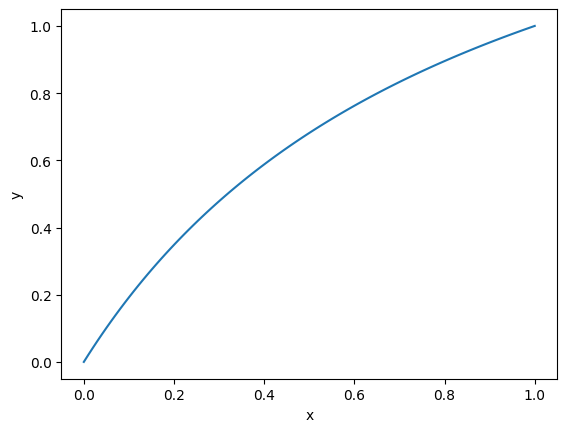

In [40]:
# 메탄올수용액의 액상몰분율-기상몰분율 그래프.

import matplotlib.pyplot as plt
import numpy as np
from CoolProp.CoolProp import PropsSI
import pandas as pd

T=298



x=np.linspace(0,1,100)
Tb=[]

def y(x):
    '''
    fluid=f"HEOS::Ethanol[{x}]&Water[{1-x}]"
    Tb=PropsSI('T','P',101325,'Q',0,fluid)
    '''
    ps=PropsSI('P','T',397,'Q',0,'Ethanol')
    pp=PropsSI('P','T',397,'Q',0,'water')
    alp=ps/pp
    return alp*x/(1+(alp-1)*x)

    

plt.plot(x,y(x))
plt.xlabel('x')
plt.ylabel('y')

In [41]:
# 상수들..


#kg/mol
M_me=PropsSI('M','T',T,'P',101325,'Ethanol')
M_water=PropsSI('M','T',T,'P',101325,'water')

#kg/m**3
rho_me=PropsSI('D','T',T,'P',101325,'Ethanol')
rho_water=PropsSI('D','T',T,'P',101325,'water')

V_bottle=25/1e6

                

In [42]:
# 95% 용액으로 농도 조절하기.......

rho_solution=1
C=np.array([0.2,0.4,0.6,0.8])
V_tot=500/1e6 #ml를 m**3으로 변환
r=[]


r=(V_tot*C/0.95)
    
print(r*10**6) # m**3을 ml로 변환


[105.26315789 210.52631579 315.78947368 421.05263158]


기울기-0.0021672587859424917
절편1.0148902236421724
1.01272296485623


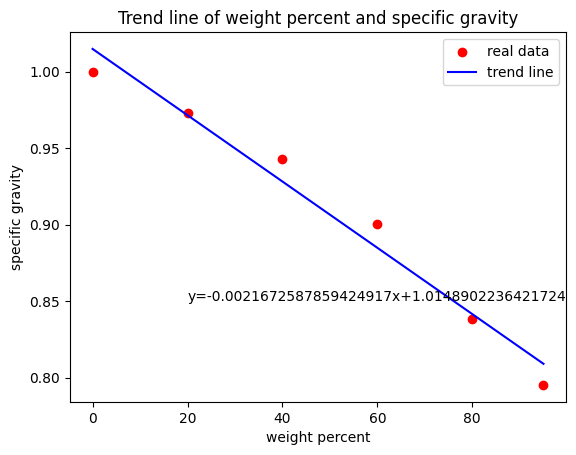

In [98]:
#검량선

from scipy import stats

y12=np.array([1,0.973,0.9429,0.9003,0.8386,0.7952])
x12=np.array([0,20,40,60,80,95])

slope, intercept, r, p, std_err = stats.linregress(x12, y12)

print(f'기울기{slope}')
print(f'절편{intercept}')

def y_fit_f(x123):
    return slope*x123+intercept

y_fit=slope*x12+intercept

plt.scatter(x12,y12,label='real data',color='red')
plt.plot(x12,y_fit,label='trend line',color='blue')
plt.annotate(f'y={slope}x+{intercept}',xy=(20,0.85),xytext=(20,0.85))
plt.legend()
plt.xlabel('weight percent')
plt.ylabel('specific gravity')
plt.title('Trend line of weight percent and specific gravity')



print(-0.0021672587859424917+1.0148902236421724)


In [101]:
# 용액의 질량, 부피, 용매와 용질의 밀도를 알때 용질의 몰분율 구하기

rrho_water=1205.312
s=27.9471/1000


sl=-0.0021672587859424917
b=1.0148902236421724

def qwer(q):
    return sl*q+b


rrho_methanol=qwer(0)*rrho_water

print('총질량',s)
print('물밀', qwer(1)*rrho_water)
#print(molfraction_of_Methanol(s,V_bottle,qwer(1)*rrho_water,rrho_methanol))



# 비중을 주면 질량퍼센트...
def weight(rho):
    return (rho-b)/(sl*100)



def molfraction_of_Methanol(m,rho):
    m_me=weight(rho)*m
    #print('메탄올질량',m_me)
    m_water=m-m_me
    #print('물질량',m_water)

    print('질량분율',m_me/(m_me+m_water))
    print('에탄올몰수',(m_me/M_me))
    print('물몰수',(m_water/M_water))

    X=(m_me/M_me)/((m_me/M_me)+(m_water/M_water))

    return X

print(molfraction_of_Methanol(s,0.927464))



총질량 0.0279471
물밀 1220.6471422167922
질량분율 0.40339540533528295
에탄올몰수 0.2447170282398467
물몰수 0.9255131962263515
0.20911870427161


In [102]:
# 몰분율계산..

xF=molfraction_of_Methanol(s,0.927464)
xD=molfraction_of_Methanol((25.1058/1000),0.833172)
xB=molfraction_of_Methanol((29.5214/1000),0.9797)

print('xf',xF)
print('xD',xD)
print('xB',xB)


xF_reflux=xF
xD_reflux=molfraction_of_Methanol((24.9014/1000),0.826389)
xB_reflux=molfraction_of_Methanol((28.7368/1000),0.953672)

print('xD_reflux',xD_reflux)
print('xB_reflux',xB_reflux)




질량분율 0.40339540533528295
에탄올몰수 0.2447170282398467
물몰수 0.9255131962263515
질량분율 0.8384703516758256
에탄올몰수 0.456939044497772
물몰수 0.22510522990260579
질량분율 0.16237204283321877
에탄올몰수 0.10405062609666364
물몰수 1.3726107196797412
xf 0.20911870427161
xD 0.669955106506087
xB 0.0704634318452722
질량분율 0.8697679523315324
에탄올몰수 0.47013616454536805
물몰수 0.1800117717822227
질량분율 0.2824684529565768
에탄올몰수 0.17619957261245564
물몰수 1.144560300800268
xD_reflux 0.7231218285502333
xB_reflux 0.1334077269906542


In [46]:
# 상부생성량 D계산...

'''
D=(df['FX']-df['BX'])/(df['DX']-df['BX'])*F
df['D']=D

R=df['Reflux'].ffill()/df['D']

df['R']=R
'''


"\nD=(df['FX']-df['BX'])/(df['DX']-df['BX'])*F\ndf['D']=D\n\nR=df['Reflux'].ffill()/df['D']\n\ndf['R']=R\n"

"\nxx1=xD\n\n\nfor i in range(10):\n    yy1=f1(xx1,xD)\n    xx2=yy1/(alp-(alp-1)*yy1)\n    #plt.axhline(y=yy1,xmin=xx1,xmax=xx2)\n    plt.plot([xx1,xx2],[yy1,yy1])\n\n    #plt.annotate(f'({xx2},{yy1})',xy=(xx2,yy1),xytext=(xx2,yy1+0.1),fontsize=8)\n\n    yy2=f1(xx2,xD)\n\n    #plt.axvline(x=xx2,ymin=yy2,ymax=yy1)\n    plt.plot([xx2,xx2],[yy1,yy2])\n\n    print('xx1',xx1,f'{i}번쨰')\n    print('xx2',xx2,f'{i}번쨰')\n    print('yy1',yy1,f'{i}번쨰')\n    print('yy2',yy2,f'{i}번쨰')\n\n    if y(xx2)-f1(xx2,xD)<1e-3:\n        print('이론단수',i)\n        break\n\n    xx1=xx2\n\nplt.legend()\nplt.title('Before reflux Rectifying-section operating line')\n"

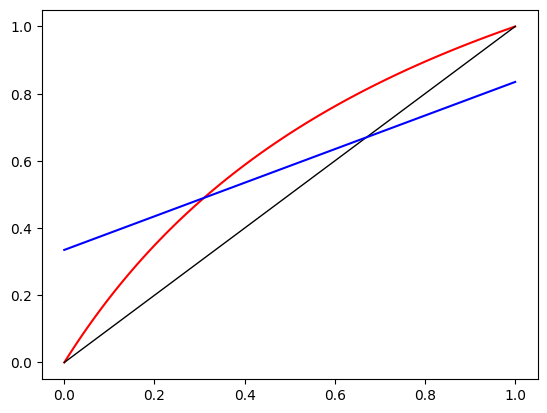

In [55]:
# Before feflux Macabe-Thiele 1

RR=1


plt.figure()
plt.plot(x,y(x),label='Equilibrium curve',color='red')
plt.plot(x,x,label='line',linewidth=1,color='black')

def f1(k,xd):
    return (RR/(RR+1))*k+(1/(RR+1))*xd
    
plt.plot(x,f1(x,xD),label='f1',color='blue')

'''
xx1=xD


for i in range(10):
    yy1=f1(xx1,xD)
    xx2=yy1/(alp-(alp-1)*yy1)
    #plt.axhline(y=yy1,xmin=xx1,xmax=xx2)
    plt.plot([xx1,xx2],[yy1,yy1])

    #plt.annotate(f'({xx2},{yy1})',xy=(xx2,yy1),xytext=(xx2,yy1+0.1),fontsize=8)

    yy2=f1(xx2,xD)
    
    #plt.axvline(x=xx2,ymin=yy2,ymax=yy1)
    plt.plot([xx2,xx2],[yy1,yy2])

    print('xx1',xx1,f'{i}번쨰')
    print('xx2',xx2,f'{i}번쨰')
    print('yy1',yy1,f'{i}번쨰')
    print('yy2',yy2,f'{i}번쨰')
  
    if y(xx2)-f1(xx2,xD)<1e-3:
        print('이론단수',i)
        break

    xx1=xx2

plt.legend()
plt.title('Before reflux Rectifying-section operating line')
'''


In [63]:
#2. 

V=8.8

def f2(k,xb):
    return ((22.6+8.8)/V)*k-(22.6*xb/V)

'''

plt.figure()
plt.plot(x,y(x),label='Equilibrium curve',color='red')
plt.plot(x,x,label='line',linewidth=1,color='black')

    
plt.plot(x,f2(x,xB),label='f2',color='blue')


xx1=xB

for i in range(10):
    #yy1=f2(xx1)
    #xx2=yy1/(alp-(alp-1)*yy1)
    yy1=xx1/(alp-(alp-1)*xx1)
    xx2=(V/(V+1))*(yy1+xB/V)
 
    plt.plot([xx1,xx2],[yy1,yy1])

    plt.annotate(f'({xx2},{yy1})',xy=(xx2,yy1),xytext=(xx2,yy1+0.1),fontsize=8)

    yy2=y(xx2)
    
    #plt.axvline(x=xx2,ymin=yy2,ymax=yy1)
    plt.plot([xx2,xx2],[yy1,yy2])

    print('xx1',xx1,f'{i}번쨰')
    print('xx2',xx2,f'{i}번쨰')
    print('yy1',yy1,f'{i}번쨰')
    print('yy2',yy2,f'{i}번쨰')

    xx1=xx2

plt.legend()
'''    

"\n\nplt.figure()\nplt.plot(x,y(x),label='Equilibrium curve',color='red')\nplt.plot(x,x,label='line',linewidth=1,color='black')\n\n\nplt.plot(x,f2(x,xB),label='f2',color='blue')\n\n\nxx1=xB\n\nfor i in range(10):\n    #yy1=f2(xx1)\n    #xx2=yy1/(alp-(alp-1)*yy1)\n    yy1=xx1/(alp-(alp-1)*xx1)\n    xx2=(V/(V+1))*(yy1+xB/V)\n\n    plt.plot([xx1,xx2],[yy1,yy1])\n\n    plt.annotate(f'({xx2},{yy1})',xy=(xx2,yy1),xytext=(xx2,yy1+0.1),fontsize=8)\n\n    yy2=y(xx2)\n\n    #plt.axvline(x=xx2,ymin=yy2,ymax=yy1)\n    plt.plot([xx2,xx2],[yy1,yy2])\n\n    print('xx1',xx1,f'{i}번쨰')\n    print('xx2',xx2,f'{i}번쨰')\n    print('yy1',yy1,f'{i}번쨰')\n    print('yy2',yy2,f'{i}번쨰')\n\n    xx1=xx2\n\nplt.legend()\n"

In [49]:
# Before reflux q-line
#q=1, liquid


'''
plt.figure()
plt.plot(x,y(x),label='Equilibrium curve',color='black')
plt.plot(x,x,label='line',linewidth=1,color='black')

xp=xF

x1=np.linspace(xp,xD,10)
x2=np.linspace(xB,xp,10)
plt.plot(x1,f1(x1,xD),label='f1',color='green')
plt.plot(x2,f2(x2,xB),label='f2',color='pink')
plt.plot([xp,xp],[0,f1(xp,xD)],label='qline',color='blue')
plt.plot([xF,xF],[0,xF],color='red')
plt.plot([xD,xD],[0,xD],color='red')
plt.plot([xB,xB],[0,xB],color='red')




xx1=xD
def x_f(y):
    return y/(alp-(alp-1)*y)

for i in range(10):
    if xx1>xF: 
        F=f1
        x_val=xD
    else:
        F=f2
        x_val=xB
        
    yy1=F(xx1,x_val)
    xx2=x_f(xx1)
    yy2=F(xx2,x_val)
    plt.plot([xx1,xx2],[yy1,yy1])
    plt.plot([xx2,xx2],[yy1,yy2])

    #plt.annotate(f'({xx2},{yy1})',xy=(xx2,yy1),xytext=(xx2,yy1+0.1),fontsize=8)

    
    #plt.axvline(x=xx2,ymin=yy2,ymax=yy1)

    print('xx1',xx1,f'{i}번쨰')
    print('xx2',xx2,f'{i}번쨰')
    print('yy1',yy1,f'{i}번쨰')
    print('yy2',yy2,f'{i}번쨰')

    if (xx2-xB)<1e-3:
        print('이론단수',i)
        break

    xx1=xx2

plt.legend()
plt.title('Before reflux q line')

'''

"\nplt.figure()\nplt.plot(x,y(x),label='Equilibrium curve',color='black')\nplt.plot(x,x,label='line',linewidth=1,color='black')\n\nxp=xF\n\nx1=np.linspace(xp,xD,10)\nx2=np.linspace(xB,xp,10)\nplt.plot(x1,f1(x1,xD),label='f1',color='green')\nplt.plot(x2,f2(x2,xB),label='f2',color='pink')\nplt.plot([xp,xp],[0,f1(xp,xD)],label='qline',color='blue')\nplt.plot([xF,xF],[0,xF],color='red')\nplt.plot([xD,xD],[0,xD],color='red')\nplt.plot([xB,xB],[0,xB],color='red')\n\n\n\n\nxx1=xD\ndef x_f(y):\n    return y/(alp-(alp-1)*y)\n\nfor i in range(10):\n    if xx1>xF: \n        F=f1\n        x_val=xD\n    else:\n        F=f2\n        x_val=xB\n\n    yy1=F(xx1,x_val)\n    xx2=x_f(xx1)\n    yy2=F(xx2,x_val)\n    plt.plot([xx1,xx2],[yy1,yy1])\n    plt.plot([xx2,xx2],[yy1,yy2])\n\n    #plt.annotate(f'({xx2},{yy1})',xy=(xx2,yy1),xytext=(xx2,yy1+0.1),fontsize=8)\n\n\n    #plt.axvline(x=xx2,ymin=yy2,ymax=yy1)\n\n    print('xx1',xx1,f'{i}번쨰')\n    print('xx2',xx2,f'{i}번쨰')\n    print('yy1',yy1,f'{i}번쨰')\n   

[2.]
100876.29794827178


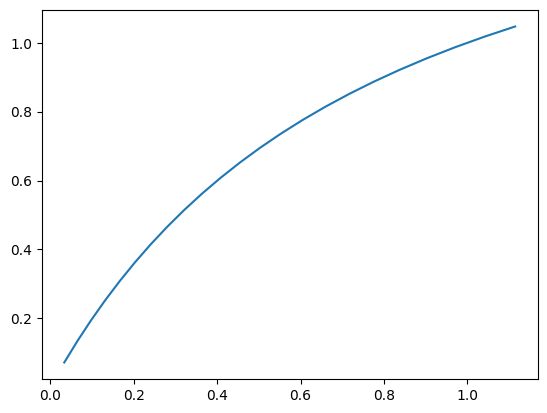

In [50]:
import scipy
#x=np.linspace(-10,10,100)
print(scipy.optimize.fsolve(lambda xxx:xxx**2-4,5))

x_test=[]
y_test=[]

for T in range(350,373):
    ww=(101325-PropsSI('P','T',T,'Q',0,'water'))/(PropsSI('P','T',T,'Q',0,'Ethanol')-PropsSI('P','T',T,'Q',0,'water'))
    x_test.append(ww)
    y_test.append(PropsSI('P','T',T,'Q',0,'Ethanol')*ww/101325)

print(PropsSI('P','T',373,'Q',0,'water'))

plt.plot(x_test,y_test)

0.9552955058486938 0.9523456390353506
0.8588352826290695 0.8449655092945703


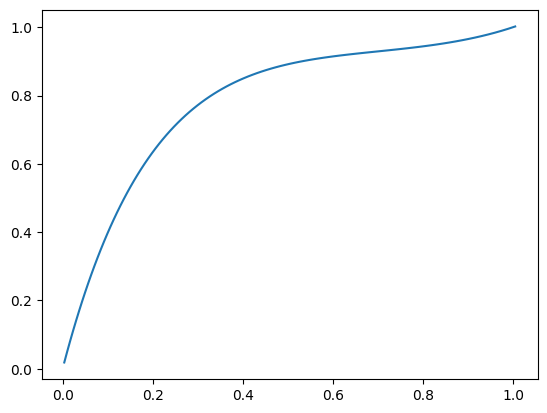

In [51]:
#NTRL모델로 비이상성을 고려한 액상-기상 몰분율 그래프
# 파라미터의 출처가 불분명함....

#단위 cal/mol
alpha=0.3
b12=612.01
b21=131.05
R=1.987

def tau12(T):
    return (b12/(R*T))
def tau21(T):
    return (b21/(R*T))



def gamma(x,T):
    x2=1-x

    G12=np.exp(-alpha*tau12(T))
    G21=np.exp(-alpha*tau21(T))

    
    
    lngamma=x2**2*(tau21(T)*(G21/(x+x2*G21)**2)+G12*tau12(T)/(x2+x*G12**2))

    return np.exp(lngamma)


Ts=np.linspace(351.5,373,100)

x_n=[]
y_n=[]

for T in Ts:
    p2=PropsSI('P','T',T,'Q',0,'water')
    p1=PropsSI('P','T',T,'Q',0,'Ethanol')
    x_N=(101325-p2)/(p1-p2)
    x_n.append(x_N)
    gama=gamma(x_N,T)
    y_N=x_N*gama*p1
    y_n.append(y_N/101325)

plt.plot(x_n,y_n)

print(y_n[10],y_n[11])
print(x_n[10],x_n[11])

def finding(y):
    for i in range(len(y_n)):
        if y-y_n[i]<1e-3:
            return x[i]


#def find

C:\Users\User\AppData\Local\Temp\ipykernel_7856\2165510167.py:48: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  x_N=fsolve(lambda x:P_tot(T,x)-101325,0.55)[0]


0.205368806839082


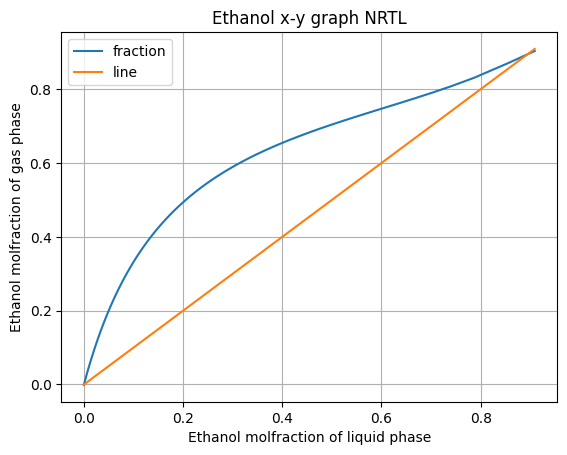

In [52]:
#NTRL모델로 비이상성을 고려한 액상-기상 몰분율 그래프
# 파라미터의 출처가 불분명함....

from scipy.optimize import fsolve

#단위 cal/mol
alpha=0.3
b12=612.01
b21=131.05
R=1.987

def tau12(T):
    return (b12/(R*T))
def tau21(T):
    return (b21/(R*T))



def gamma(x,T):
    x2=1-x

    G12=np.exp(-alpha*tau12(T))
    G21=np.exp(-alpha*tau21(T))

    lngamma1=x2**2*(tau21(T)*((G21/(x+x2*G21))**2)+G12*tau12(T)/(x2+x*G12)**2)
    lngamma2=x**2*(tau12(T)*((G12/(x2+x*G12))**2)+G21*tau21(T)/(x+x2*G21)**2)

    return [np.exp(lngamma1),np.exp(lngamma2)]


Ts=np.linspace(351.15,373.15,100)

x_n=[]
y_n=[]


def P_tot(T,xa):
    return PropsSI('P','T',T,'Q',0,'Ethanol')*xa*gamma(xa,T)[0]+PropsSI('P','T',T,'Q',0,'water')*(1-xa)*gamma(xa,T)[1]    

for T in Ts:

    
    p2=PropsSI('P','T',T,'Q',0,'water')
    p1=PropsSI('P','T',T,'Q',0,'Ethanol')
    #x_N=(101325-p2)/(p1-p2)


    x_N=fsolve(lambda x:P_tot(T,x)-101325,0.55)[0]
    x_n.append(x_N)
    gama=gamma(x_N,T)[0]
    y_N=x_N*gama*p1
    y_n.append(y_N/101325)

plt.plot(x_n,y_n,label='fraction')
plt.plot(x_n,x_n,label='line')
plt.xlabel('Ethanol molfraction of liquid phase')
plt.ylabel('Ethanol molfraction of gas phase')
plt.title('Ethanol x-y graph NRTL')
plt.legend()
plt.grid()


#print(y_n[10],y_n[11])
#print(x_n[10],x_n[11])

# 함수관계..

# 평형온도찾기
#ying은 배열을 못받는다.

def ying(x):
    T_eq=fsolve(lambda T:P_tot(T,x)-101325,351.15)
    return x*gamma(x,T_eq)[0]*PropsSI('P','T',T_eq,'Q',0,'Ethanol')/101325

# x찾기
def xing(y):

    def equ(vars):
        x,T=vars        
        p2=PropsSI('P','T',T,'Q',0,'water')
        p1=PropsSI('P','T',T,'Q',0,'Ethanol')
        eq1=p1*x*gamma(x,T)[0]+p2*(1-x)*gamma(x,T)[1]-101325
        eq2=x*gamma(x,T)[0]*p1-y*101325

        return [eq1,eq2]

    x_sol,Tsol=fsolve(equ, [0.5,360])

    return x_sol

print(xing(0.5))

[0.22950928]
q is[1.08261775]
이론단수 5


Text(0.5, 1.0, 'q line')

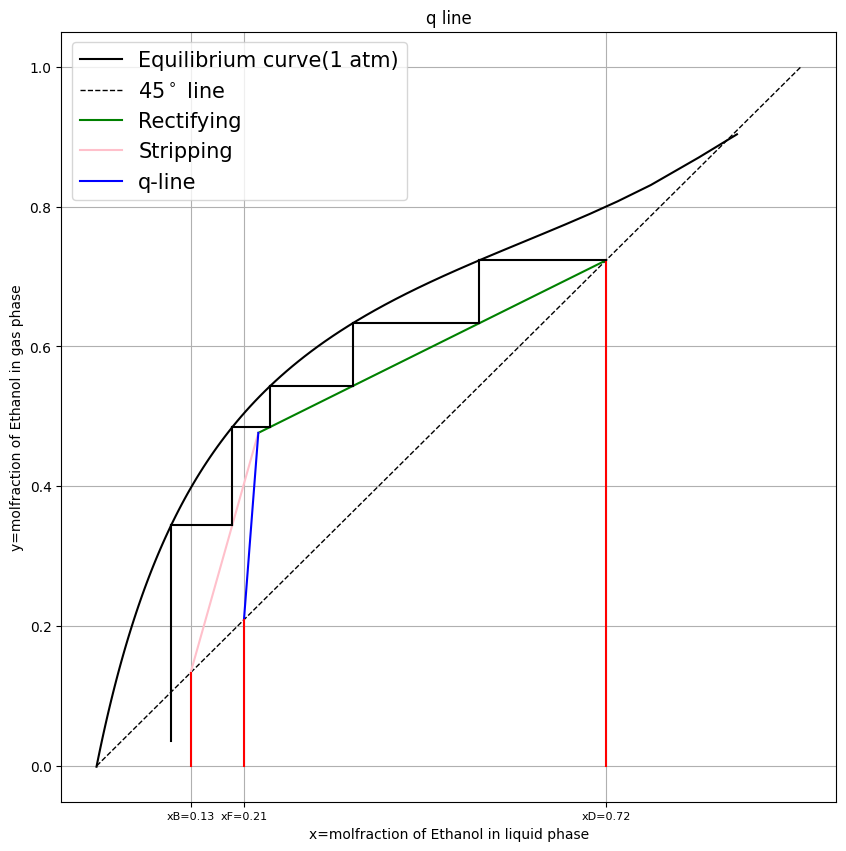

In [110]:
#  reflux q-line
#q=1, liquid



plt.figure(figsize=(10,10))
plt.plot(x_n,y_n,label='Equilibrium curve(1 atm)',color='black')
plt.plot(x,x,label=r'$45^\circ$ line',linewidth=1,color='black',linestyle='--')




# guessing q...

xp=fsolve(lambda x: f1(x,xD_reflux)-f2(x,xB_reflux),xF_reflux)

print(xp)

m=(f1(xp,xD_reflux)-xF_reflux)/(xp-xF_reflux)
q=m/(m-1)
print(f'q is{q}')

def qline(x):
    return (q/(q-1))*x-(xF_reflux/(q-1))



# guessing Teq


plt.xticks([xB_reflux,xF_reflux,xD_reflux],[f'xB={np.round(xB_reflux,2)}',f'xF={np.round(xF_reflux,2)}',f'xD={np.round(xD_reflux,2)}'],fontsize=8)
x1=np.linspace(xp,xD_reflux,10)
x2=np.linspace(xB_reflux,xp,10)
x3=np.linspace(xF_reflux,xp,10)
plt.plot(x1,f1(x1,xD_reflux),label='Rectifying',color='green')
plt.plot(x2,f2(x2,xB_reflux),label='Stripping',color='pink')
plt.plot(x3,qline(x3),label='q-line',color='blue')
plt.plot([xF_reflux,xF_reflux],[0,xF_reflux],color='red')
plt.plot([xD_reflux,xD_reflux],[0,xD_reflux],color='red')
plt.plot([xB_reflux,xB_reflux],[0,xB_reflux],color='red')


def get_func(x):
    if x>xF_reflux: 
        return f1(x,xD_reflux)
    else:
        return f2(x,xB_reflux)



xx1=xD_reflux


for i in range(10):

        
    yy1=get_func(xx1)
    xx2=xing(yy1)
    yy2=get_func(xx2)

    plt.plot([xx1,xx2],[yy1,yy1],color='black')
    plt.plot([xx2,xx2],[yy1,yy2],color='black')

    #plt.annotate(f'({xx2},{yy1})',xy=(xx2,yy1),xytext=(xx2,yy1+0.1),fontsize=8)

    
    #plt.axvline(x=xx2,ymin=yy2,ymax=yy1)
    '''
    print('xx1',xx1,f'{i}번쨰')
    print('xx2',xx2,f'{i}번쨰')
    print('yy1',yy1,f'{i}번쨰')
    print('yy2',yy2,f'{i}번쨰')
    '''
    if xx2<xB_reflux:
        print('이론단수',i+1)
        break

    xx1=xx2

plt.legend(fontsize=15)
plt.grid(True)
plt.xlabel('x=molfraction of Ethanol in liquid phase')
plt.ylabel('y=molfraction of Ethanol in gas phase')
plt.title('q line')


이론단수 5


Text(0.5, 1.0, 'q=1 line')

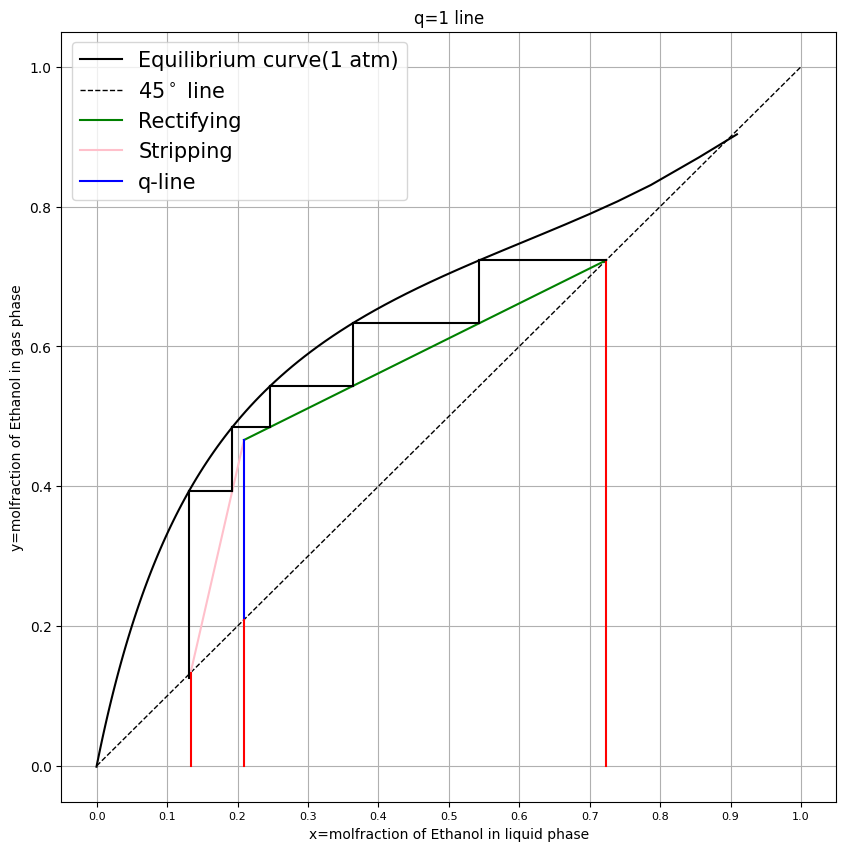

In [117]:
# q=1로 test

#  reflux q-line
#q=1, liquid



plt.figure(figsize=(10,10))
plt.plot(x_n,y_n,label='Equilibrium curve(1 atm)',color='black')
plt.plot(x,x,label=r'$45^\circ$ line',linewidth=1,color='black',linestyle='--')




# guessing q...
'''
xp=fsolve(lambda x: f1(x,xD_reflux)-f2(x,xB_reflux),xF_reflux)

print(xp)

m=(f1(xp,xD_reflux)-xF_reflux)/(xp-xF_reflux)
q=m/(m-1)
print(f'q is{q}')

def qline(x):
    return (q/(q-1))*x-(xF_reflux/(q-1))

'''


# guessing Teq

xp=xF_reflux

def f3(x,xB):
    m=(f1(xp,xD_reflux)-xB_reflux)/(xp-xB_reflux)
    n=-m*xB+xB
    return m*x+n



plt.xticks([xB_reflux,xF_reflux,xD_reflux],[f'xB={np.round(xB_reflux,2)}',f'xF={np.round(xF_reflux,2)}',f'xD={np.round(xD_reflux,2)}'],fontsize=8)
plt.xticks(np.arange(0, 1.1, 0.1), [f'{i:.1f}' for i in np.arange(0, 1.1, 0.1)])
x1=np.linspace(xp,xD_reflux,10)
x2=np.linspace(xB_reflux,xp,10)
x3=np.linspace(xF_reflux,xp,10)
plt.plot(x1,f1(x1,xD_reflux),label='Rectifying',color='green')
plt.plot(x2,f3(x2,xB_reflux),label='Stripping',color='pink')
plt.plot([xp,xp],[f1(xp,xD_reflux),xp],label='q-line',color='blue')
plt.plot([xF_reflux,xF_reflux],[0,xF_reflux],color='red')
plt.plot([xD_reflux,xD_reflux],[0,xD_reflux],color='red')
plt.plot([xB_reflux,xB_reflux],[0,xB_reflux],color='red')




def get_func(x):
    if x>xF_reflux: 
        return f1(x,xD_reflux)
    else:
        return f3(x,xB_reflux)



xx1=xD_reflux


for i in range(10):

        
    yy1=get_func(xx1)
    xx2=xing(yy1)
    yy2=get_func(xx2)

    plt.plot([xx1,xx2],[yy1,yy1],color='black')
    plt.plot([xx2,xx2],[yy1,yy2],color='black')

    #plt.annotate(f'({xx2},{yy1})',xy=(xx2,yy1),xytext=(xx2,yy1+0.1),fontsize=8)

    
    #plt.axvline(x=xx2,ymin=yy2,ymax=yy1)
    '''
    print('xx1',xx1,f'{i}번쨰')
    print('xx2',xx2,f'{i}번쨰')
    print('yy1',yy1,f'{i}번쨰')
    print('yy2',yy2,f'{i}번쨰')
    '''
    if xx2<xB_reflux:
        print('이론단수',i+1)
        break

    xx1=xx2

plt.legend(fontsize=15)
plt.grid(True)
plt.xlabel('x=molfraction of Ethanol in liquid phase')
plt.ylabel('y=molfraction of Ethanol in gas phase')
plt.title('q=1 line')

